In [1]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 5.2 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.5 MB 5.5 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 5.9 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 6.1 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 5.8 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 5.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 5.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 5.3 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 5.1 MB/s  0:00:01
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
    --------------------------------------- 0.5/36.6 MB 3.5 MB/s eta 0:00:11
   - ----------------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
!pip install scikit-learn

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/processed/model_ready_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

series = df[["Date", "NVDA_Close"]].copy()
series = series.set_index("Date")

series.head()

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 3.3 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.2 MB 3.7 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.2 MB 4.0 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.2 MB 4.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.2 MB 3.8 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.2 MB 4.0 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 3.9 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 3.8 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 MB 3.9 MB/s eta 0:00:01
   ------------------------------------- -- 7.

,NVDA_Close
Date,
2010-05-12,0.336068
2010-05-13,0.335382
2010-05-14,0.296693
2010-05-17,0.297379
2010-05-18,0.287535


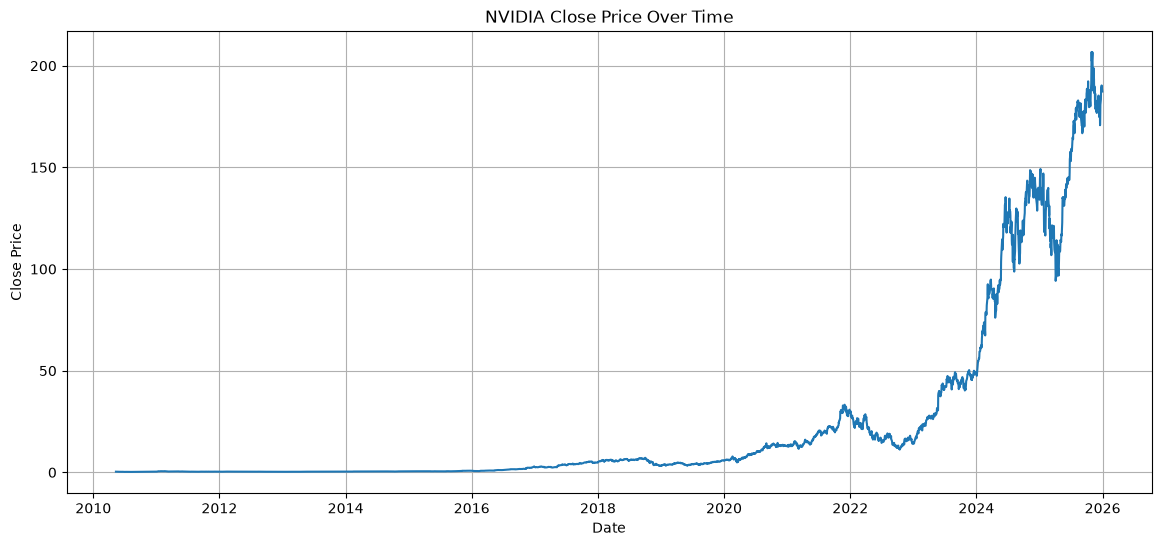

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(series.index, series["NVDA_Close"])
plt.title("NVIDIA Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

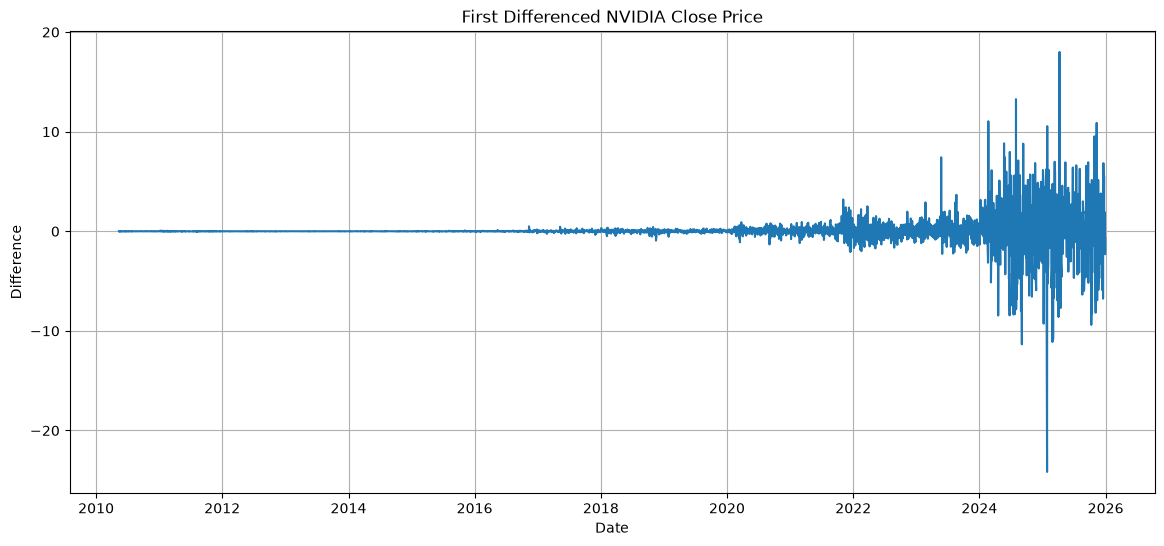

In [6]:
series["NVDA_Close_Diff"] = series["NVDA_Close"].diff()

plt.figure(figsize=(14, 6))
plt.plot(series.index, series["NVDA_Close_Diff"])
plt.title("First Differenced NVIDIA Close Price")
plt.xlabel("Date")
plt.ylabel("Difference")
plt.grid(True)
plt.show()

In [8]:
target_series = series["NVDA_Close"]

split_index = int(len(target_series) * 0.8)

train = target_series.iloc[:split_index]
test = target_series.iloc[split_index:]

print("Train:", train.index.min(), "to", train.index.max())
print("Test:", test.index.min(), "to", test.index.max())

Train: 2010-05-12 00:00:00 to 2022-11-09 00:00:00
Test: 2022-11-10 00:00:00 to 2025-12-30 00:00:00


In [18]:
history = list(train)
predictions = []

for actual in test:
    model = ARIMA(history, order=(5, 1, 0))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(actual)

results_walk = pd.DataFrame({
    "Actual": test.values,
    "Forecast": predictions
}, index=test.index)

mae = mean_absolute_error(results_walk["Actual"], results_walk["Forecast"])
rmse = np.sqrt(mean_squared_error(results_walk["Actual"], results_walk["Forecast"]))
r2 = r2_score(results_walk["Actual"], results_walk["Forecast"])

print("Walk-Forward ARIMA Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Walk-Forward ARIMA Results
MAE: 2.0943205509556266
RMSE: 3.1839411218548754
R2 Score: 0.99667622819067


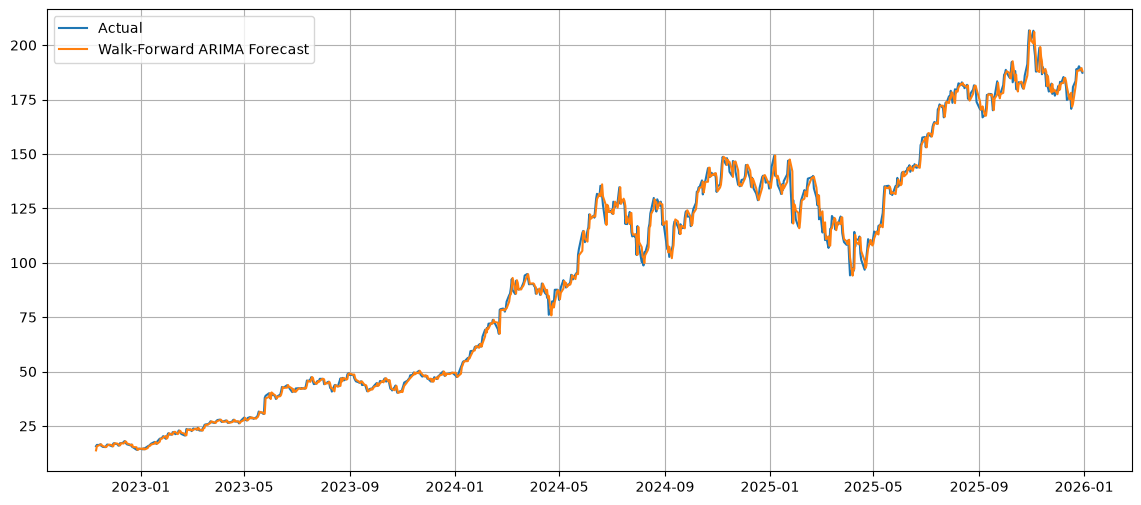

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(results_walk.index, results_walk["Actual"], label="Actual")
plt.plot(results_walk.index, results_walk["Forecast"], label="Walk-Forward ARIMA Forecast")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
print(df.columns.tolist())

['Date', 'NVDA_Open', 'NVDA_High', 'NVDA_Low', 'NVDA_Close', 'NVDA_Volume', 'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Close', 'SP500_Volume', 'Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume', 'Oil_Open', 'Oil_High', 'Oil_Low', 'Oil_Close', 'Oil_Volume', 'Treasury10Y_Open', 'Treasury10Y_High', 'Treasury10Y_Low', 'Treasury10Y_Close', 'Treasury10Y_Volume', 'VIX_Open', 'VIX_High', 'VIX_Low', 'VIX_Close', 'VIX_Volume', 'NVDA_Return', 'NVDA_SMA_7', 'NVDA_SMA_30', 'NVDA_SMA_90', 'NVDA_EMA_12', 'NVDA_EMA_26', 'NVDA_MACD', 'NVDA_MACD_Signal', 'NVDA_Volatility_7', 'NVDA_Volatility_30', 'NVDA_Close_Lag_1', 'NVDA_Close_Lag_7', 'NVDA_Close_Lag_30', 'Target_Next_Close']


In [21]:
mape_arima = np.mean(
    np.abs((results_walk["Actual"] - results_walk["Forecast"]) / results_walk["Actual"])
) * 100

print("ARIMA MAPE:", mape_arima)

ARIMA MAPE: 2.2857830353573894
